In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset_builder

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
sns.set_style(style="whitegrid")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

EVAL_ROOT = Path("../eval_results")

/Users/david/eurosat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def latest_run(eval_root: Path, prefix: str) -> Path:
    runs = [p for p in eval_root.iterdir() if p.is_dir() and p.name.startswith(prefix)]
    if not runs:
        raise FileNotFoundError(f"No runs found with prefix '{prefix}' in {eval_root}")
    return sorted(runs)[-1]

msi_run_dir = latest_run(EVAL_ROOT, "msi_")

rgb_run_dir = latest_run(EVAL_ROOT, "rgb_")

msi_run_dir, rgb_run_dir

(PosixPath('../eval_results/msi_msi_e15_best_20260426_233035'),
 PosixPath('../eval_results/rgb_rgb_e15_best_20260426_011220'))

In [ ]:
metrics_path = msi_run_dir / "metrics.json"
report_path = msi_run_dir / "classification_report.json"
cm_path = msi_run_dir / "confusion_matrix.csv"
cmn_path = msi_run_dir / "confusion_matrix_normalized.csv"
band_csv_path = msi_run_dir / "band_importance.csv"
band_json_path = msi_run_dir / "band_importance.json"

with open(metrics_path) as f:
    msi_metrics = json.load(f)
with open(report_path) as f:
    msi_report = json.load(f)

cm = np.loadtxt(cm_path, delimiter=",")
cm_norm = np.loadtxt(cmn_path, delimiter=",")
if cm.ndim == 1:
    cm = cm.reshape(1, -1)
if cm_norm.ndim == 1:
    cm_norm = cm_norm.reshape(1, -1)

if band_csv_path.exists():
    band_df = pd.read_csv(band_csv_path)
elif band_json_path.exists():
    with open(band_json_path) as f:
        band_df = pd.DataFrame(json.load(f))
else:
    band_df = pd.DataFrame()  # MSI band importance missing if eval ran before feature was added

num_classes = cm.shape[0]
class_names = load_dataset_builder("blanchon/EuroSAT_MSI").info.features["label"].names
if len(class_names) != num_classes:
    raise ValueError(f"Expected {num_classes} class names, got {len(class_names)}")

msi_metrics

{'accuracy': 0.9807407407407407,
 'balanced_accuracy': 0.9800198889624486,
 'macro_f1': 0.9801190499767591,
 'weighted_f1': 0.9807268372105193,
 'kappa': 0.9785643266959975}

In [4]:
overall_msi = pd.DataFrame([{
    "accuracy": msi_metrics.get("accuracy"),
    "macro_f1": msi_metrics.get("macro_f1"),
    "weighted_f1": msi_metrics.get("weighted_f1"),
    "balanced_accuracy": msi_metrics.get("balanced_accuracy"),
    "kappa": msi_metrics.get("kappa"),
}]).round(4)

overall_msi

,accuracy,macro_f1,weighted_f1,balanced_accuracy,kappa
0,0.9807,0.9801,0.9807,0.98,0.9786


In [5]:
rows = []
for k, v in msi_report.items():
    if isinstance(v, dict) and "precision" in v and "f1-score" in v:
        if k not in ["accuracy", "macro avg", "weighted avg"]:
            rows.append({
                "class": k,
                "precision": v["precision"],
                "f1": v["f1-score"],
                "recall": v["recall"],
                "support": v["support"],
            })

per_class_msi = pd.DataFrame(rows).sort_values("class").reset_index(drop=True)
per_class_msi.round(4)

,class,precision,f1,recall,support
0,0,0.9742,0.9789,0.9837,613.0
1,1,0.9918,0.9942,0.9967,605.0
2,2,0.9761,0.9753,0.9745,628.0
3,3,0.9837,0.9768,0.9699,499.0
4,4,0.9804,0.9823,0.9842,507.0
5,5,0.9707,0.9719,0.9731,409.0
6,6,0.9705,0.9634,0.9563,481.0
7,7,0.9913,0.9871,0.9828,583.0
8,8,0.9710,0.9767,0.9824,511.0
9,9,0.9929,0.9947,0.9965,564.0


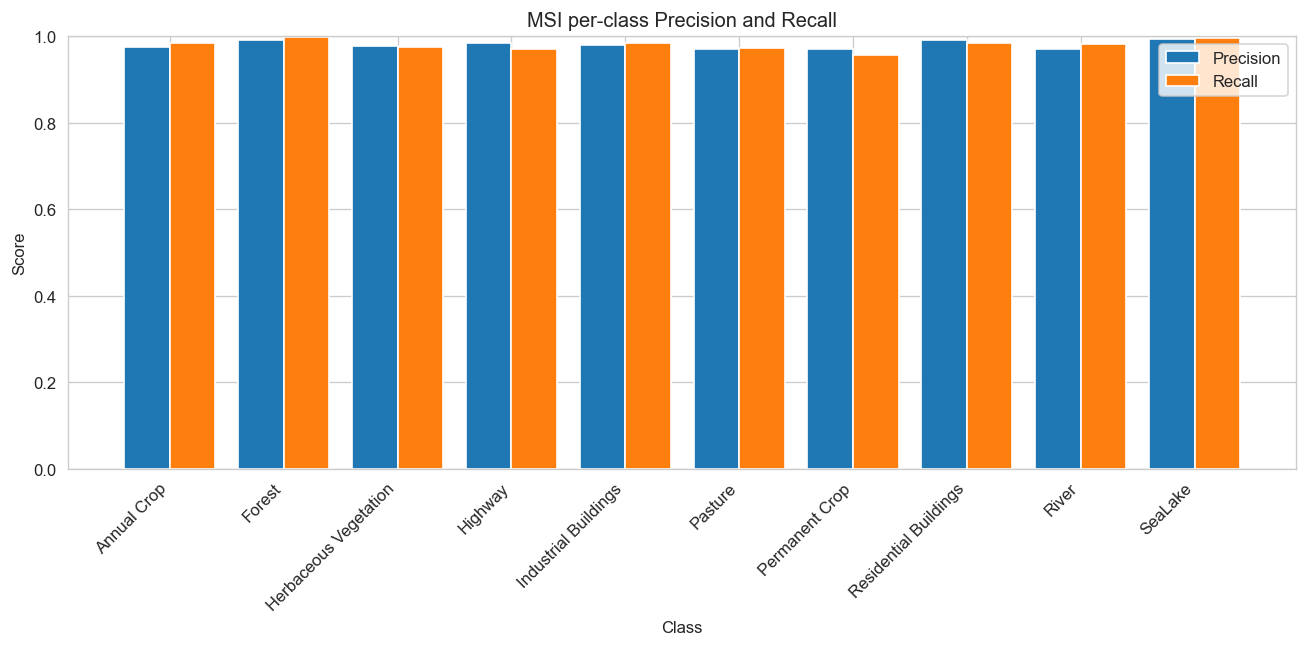

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(per_class_msi))
w = 0.4
class_labels = [class_names[int(class_id)] for class_id in per_class_msi["class"]]

ax.bar(x - w/2, per_class_msi["precision"], width=w, label="Precision")
ax.bar(x + w/2, per_class_msi["recall"], width=w, label="Recall")

ax.set_title("MSI per-class Precision and Recall")
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.legend()
fig.tight_layout()

fig.savefig(FIG_DIR / "msi_eval_precision_recall.png", bbox_inches="tight")
plt.show()

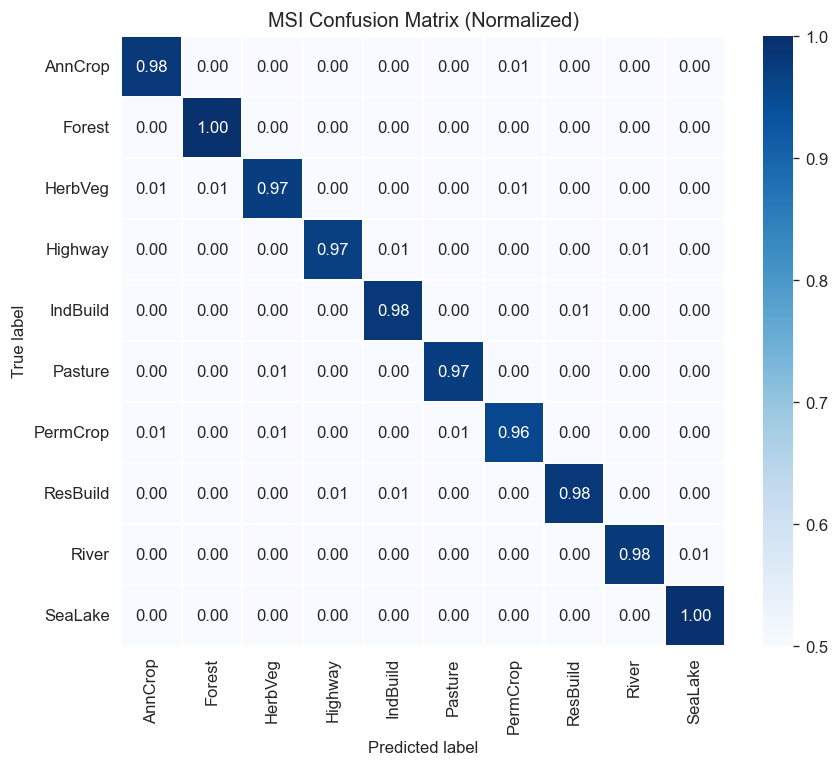

In [7]:
class_names_short = [
    "AnnCrop", "Forest", "HerbVeg", "Highway", "IndBuild",
    "Pasture", "PermCrop", "ResBuild", "River", "SeaLake"
]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    vmin=0.5, vmax=1.0,
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    cbar=True,
    xticklabels=class_names_short,
    yticklabels=class_names_short,
    ax=ax
)

ax.set_title("MSI Confusion Matrix (Normalized)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
fig.tight_layout()

fig.savefig(FIG_DIR / "msi_confusion_matrix_normalized.png", bbox_inches="tight")
plt.show()

,band_index,band_name,macro_f1_masked,importance
0,7,B08,0.018913,0.961206
1,6,B07,0.190425,0.789694
2,12,B12,0.214803,0.765316
3,11,B11,0.264786,0.715333
4,0,B01,0.278574,0.701545
5,2,B03,0.283901,0.696218
6,3,B04,0.328087,0.652032
7,10,B10,0.342591,0.637528
8,4,B05,0.346839,0.633280
9,1,B02,0.388500,0.591619


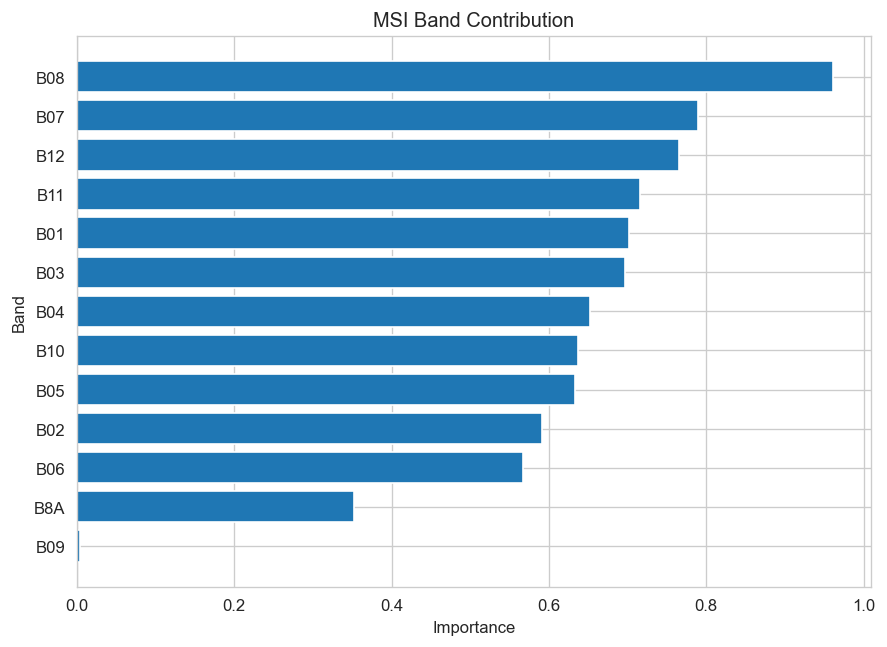

In [8]:
if band_df.empty:
    print("No band importance file found in this MSI run.")
else:
    band_df = band_df.sort_values("importance", ascending=False).reset_index(drop=True)
    display(band_df.round(6))

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.barh(band_df["band_name"], band_df["importance"])
    ax.invert_yaxis()
    ax.set_title("MSI Band Contribution")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Band")
    fig.tight_layout()

    fig.savefig(FIG_DIR / "msi_band_importance.png", bbox_inches="tight")
    plt.show()

In [9]:
with open(rgb_run_dir / "metrics.json") as f:
    rgb_metrics = json.load(f)

comparison = pd.DataFrame([{
    "rgb_macro_f1": rgb_metrics.get("macro_f1"),
    "msi_macro_f1": msi_metrics.get("macro_f1"),
    "macro_f1_gain_msi_minus_rgb": msi_metrics.get("macro_f1") - rgb_metrics.get("macro_f1"),
    "rgb_bal_acc": rgb_metrics.get("balanced_accuracy"),
    "msi_bal_acc": msi_metrics.get("balanced_accuracy"),
    "bal_acc_gain_msi_minus_rgb": msi_metrics.get("balanced_accuracy") - rgb_metrics.get("balanced_accuracy"),
}]).round(6)

display(comparison)

if not band_df.empty:
    total_gain = msi_metrics.get("macro_f1") - rgb_metrics.get("macro_f1")
    band_gain = band_df.copy()
    band_gain["attribution_ratio"] = np.nan if total_gain == 0 else (band_gain["importance"] / total_gain)
    display(band_gain[["band_name", "importance", "attribution_ratio"]].round(6).head(13))

,rgb_macro_f1,msi_macro_f1,macro_f1_gain_msi_minus_rgb,rgb_bal_acc,msi_bal_acc,bal_acc_gain_msi_minus_rgb
0,0.966873,0.980119,0.013246,0.966292,0.98002,0.013728


,band_name,importance,attribution_ratio
0,B08,0.961206,72.565699
1,B07,0.789694,59.617498
2,B12,0.765316,57.777095
3,B11,0.715333,54.003657
4,B01,0.701545,52.962740
5,B03,0.696218,52.560581
6,B04,0.652032,49.224784
7,B10,0.637528,48.129813
8,B05,0.633280,47.809112
9,B02,0.591619,44.663939
